In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Configuração visual
sns.set(style="whitegrid")

# 1. Simulação de Dados (Baseado na sua justificativa)
np.random.seed(42)
n_alunos = 200

data = {
    'id_aluno': range(1, n_alunos + 1),
    'frequencia_exercicio_semanal': np.random.randint(0, 7, n_alunos), # Dias por semana
    'interesse_competicao': np.random.randint(1, 11, n_alunos),       # Escala 1-10
    'participacao_eventos_passados': np.random.randint(0, 5, n_alunos), # Quantidade
    'horas_estudo_dia': np.random.uniform(2, 10, n_alunos),
    'distancia_campus_km': np.random.uniform(1, 30, n_alunos)
}

df = pd.DataFrame(data)

# Criando a discrepância: Alunos que treinam muito mas participam pouco
print("Primeiras linhas da base de dados processada:")
display(df.head())

Primeiras linhas da base de dados processada:


,id_aluno,frequencia_exercicio_semanal,interesse_competicao,participacao_eventos_passados,horas_estudo_dia,distancia_campus_km
0,1,6,9,1,9.793986,7.847379
1,2,3,5,0,9.967450,23.038707
2,3,4,6,4,2.446969,16.406707
3,4,6,4,3,7.896284,21.894966
4,5,2,10,1,6.367326,2.807900


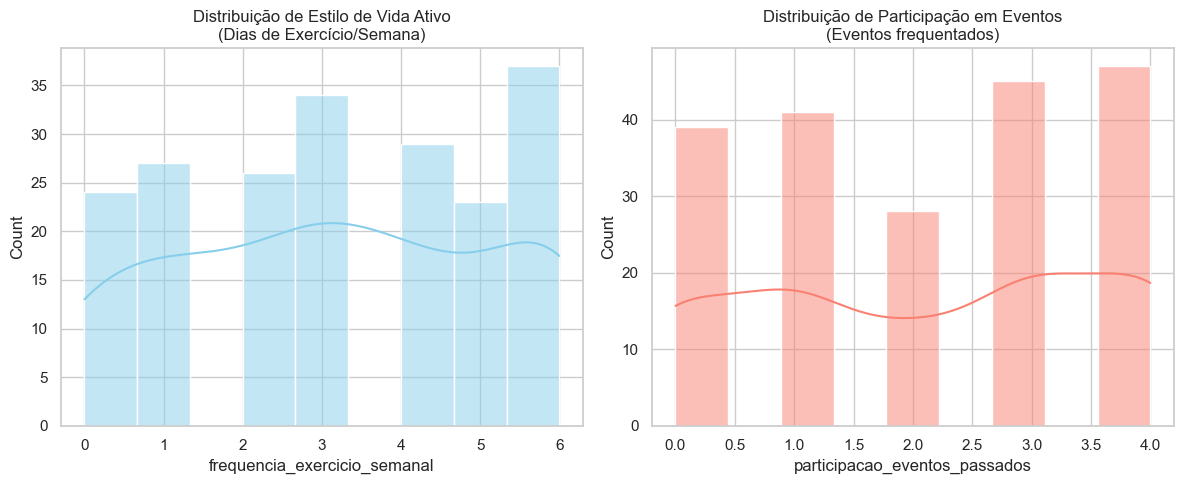

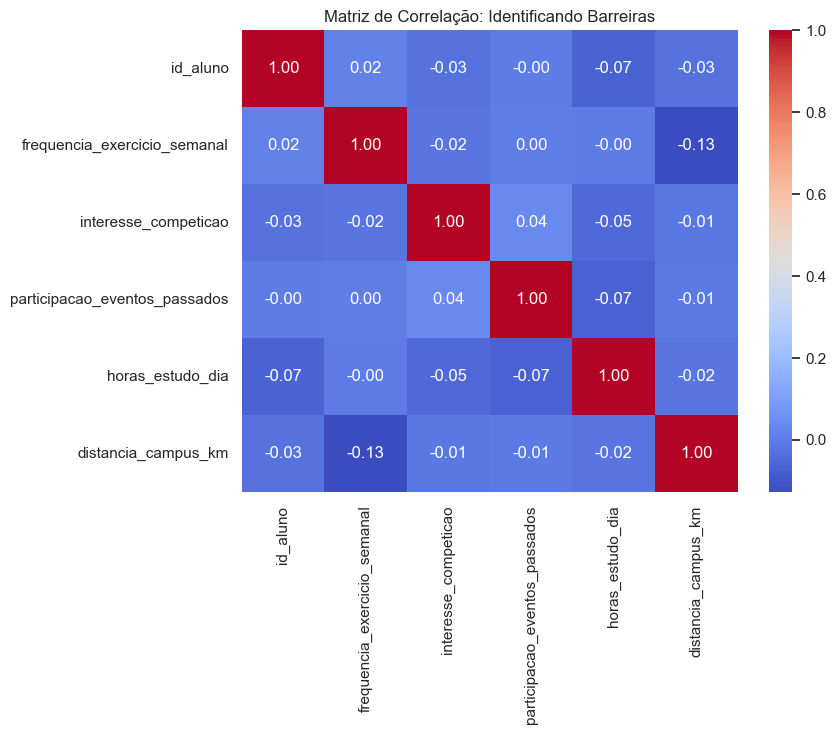

In [2]:
# Visualização 1: Histograma de Frequência de Exercícios vs Participação em Eventos
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['frequencia_exercicio_semanal'], kde=True, color='skyblue')
plt.title('Distribuição de Estilo de Vida Ativo\n(Dias de Exercício/Semana)')

plt.subplot(1, 2, 2)
sns.histplot(df['participacao_eventos_passados'], kde=True, color='salmon')
plt.title('Distribuição de Participação em Eventos\n(Eventos frequentados)')

plt.tight_layout()
plt.show()

# Insight: Correlação
corr = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação: Identificando Barreiras")
plt.show()

C:\Users\Amon\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


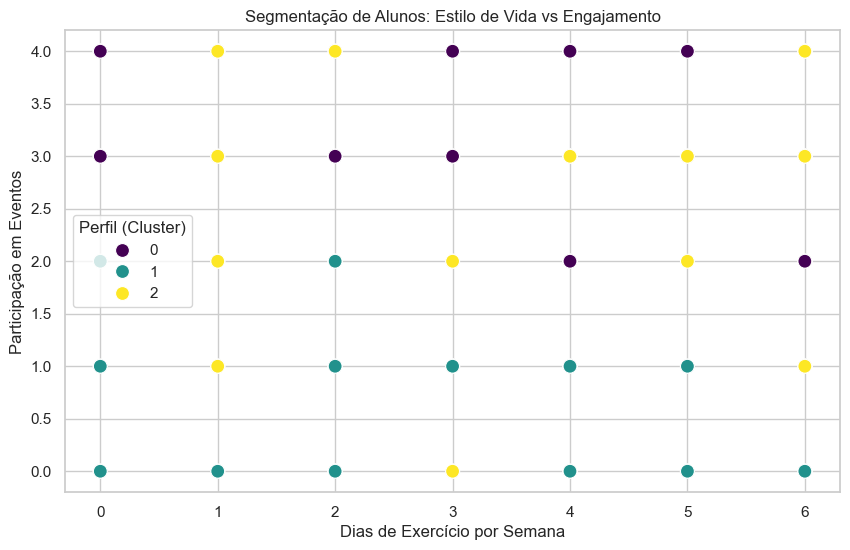

Análise dos Clusters (Médias):


,frequencia_exercicio_semanal,participacao_eventos_passados,interesse_competicao
perfil_cluster,,,
0,3.243243,3.391892,3.540541
1,2.967213,0.557377,3.327869
2,3.276923,2.076923,8.476923


In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1" # Remove o aviso de memory leak no Windows
from sklearn.cluster import KMeans

# Preparação dos dados para Clusterização
features = ['frequencia_exercicio_semanal', 'participacao_eventos_passados', 'interesse_competicao']
x = df[features]

# Normalização
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Aplicando K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['perfil_cluster'] = kmeans.fit_predict(x_scaled)

# Visualizando os Grupos
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='frequencia_exercicio_semanal', y='participacao_eventos_passados', 
                hue='perfil_cluster', palette='viridis', s=100)
plt.title("Segmentação de Alunos: Estilo de Vida vs Engajamento")
plt.xlabel("Dias de Exercício por Semana")
plt.ylabel("Participação em Eventos")
plt.legend(title='Perfil (Cluster)')
plt.show()

print("Análise dos Clusters (Médias):")
display(df.groupby('perfil_cluster')[features].mean())

In [4]:
def definir_persona(row):
    if row['frequencia_exercicio_semanal'] >= 4 and row['participacao_eventos_passados'] <= 1:
        return "Atleta de Academia (Potencial não explorado)"
    elif row['participacao_eventos_passados'] >= 3:
        return "Engajado (Promotor do evento)"
    else:
        return "Neutro/Desinteressado"

df['persona'] = df.apply(definir_persona, axis=1)
resumo_personas = df['persona'].value_counts(normalize=True) * 100

print("--- INSIGHTS PARA O PROTÓTIPO ---")
print(f"Alunos 'Atletas de Academia' que não participam: {resumo_personas.get('Atleta de Academia (Potencial não explorado)', 0):.2f}%")

--- INSIGHTS PARA O PROTÓTIPO ---
Alunos 'Atletas de Academia' que não participam: 16.50%
